In [ ]:
import pandas as pd

# Import Data-set

In [ ]:
df = pd.read_csv("Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# Identifying Unique Elements

In [ ]:
df.stops.value_counts()

,count
stops,
one,250863
zero,36004
two_or_more,13286


# Checking for Missing Values and Unconverted Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


# Pre-processing
## We'll one-hot encode everything and drop unnecessary columns

In [ ]:
#dropping unnecessary columns
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Economy' else 0)
df['stops'] = pd.factorize(df['stops'])[0]
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,1,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,1,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,1,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,1,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,1,2.33,1,5955


In [ ]:
df = df.join(pd.get_dummies(df['airline'], prefix='airline')).drop('airline', axis=1)
df = df.join(pd.get_dummies(df['source_city'], prefix='source_city')).drop('source_city', axis=1)
df = df.join(pd.get_dummies(df['destination_city'], prefix='destination_city')).drop('destination_city', axis=1)
df = df.join(pd.get_dummies(df['departure_time'], prefix='departure_time')).drop('departure_time', axis=1)
df = df.join(pd.get_dummies(df['arrival_time'], prefix='arrival_time')).drop('arrival_time', axis=1)

In [ ]:
df.head()

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,1,2.17,1,5953,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,True
1,0,1,2.33,1,5953,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,0,1,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,1,2.25,1,5955,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,False
4,0,1,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False


# Using Random Forest Regressor and `train_test_split`
## split our data to training and testing and make our regression model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X, y= df.drop('price', axis=1), df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
reg = RandomForestRegressor(n_jobs=-1)
reg.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [ ]:
reg.score(X_test, y_test)

0.9853154466581789

# Check for Other Metrics like RMSE, MSE...

In [ ]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = reg.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R2: 0.9853154466581789
MSE: 1073.5628569750866
RMSE: 7615941.286483218


# Verifying our Model
We'll use `matplotlib` to display a graph that represents our predicted results with the actual ones

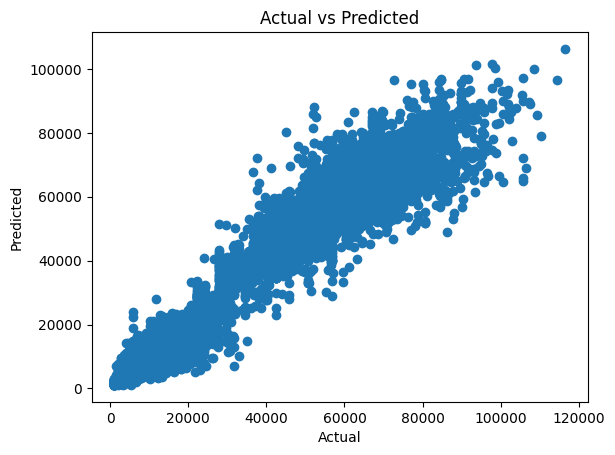

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
df.price

,price
0,5953
1,5953
2,5956
3,5955
4,5955
...,...
300148,69265
300149,77105
300150,79099
300151,81585


# Optimizing Way More

---



In [ ]:
importances = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)
sorted_importances

[('class', np.float64(0.8804567010759532)),
 ('duration', np.float64(0.05746295883490268)),
 ('days_left', np.float64(0.018432425731597778)),
 ('airline_Air_India', np.float64(0.005688303432551124)),
 ('airline_Vistara', np.float64(0.004151084088807529)),
 ('source_city_Delhi', np.float64(0.003510565580298115)),
 ('destination_city_Delhi', np.float64(0.0032051665205292124)),
 ('source_city_Mumbai', np.float64(0.0022332236262236032)),
 ('destination_city_Mumbai', np.float64(0.0020009233228031314)),
 ('source_city_Kolkata', np.float64(0.0018476204952294988)),
 ('stops', np.float64(0.001791104785201755)),
 ('destination_city_Kolkata', np.float64(0.0017435830601229781)),
 ('arrival_time_Evening', np.float64(0.0016370779675567717)),
 ('destination_city_Hyderabad', np.float64(0.0015434302157243667)),
 ('destination_city_Bangalore', np.float64(0.0013396533730847535)),
 ('source_city_Hyderabad', np.float64(0.0013392768147144085)),
 ('arrival_time_Night', np.float64(0.0011288231611030484)),
 ('

In [ ]:
df.days_left.describe()

,days_left
count,300153.000000
mean,26.004751
std,13.561004
min,1.000000
25%,15.000000
50%,26.000000
75%,38.000000
max,49.000000


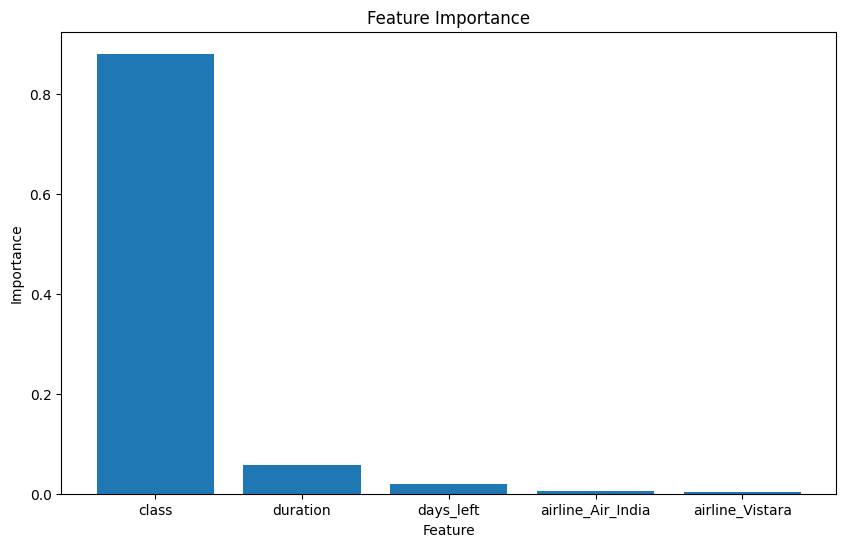

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar([x[0] for x in sorted_importances[:5]], [x[1] for x in sorted_importances[:5]])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
# We'll try fewer combinations to speed up the process
param_grid = {
    'n_estimators': [100, 200], # Reduced from [100, 200, 300]
    'max_depth': [None, 10], # Reduced from [None, 5, 10]
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto', 'sqrt']
}
# Reduced cv from 5 to 3 to further speed up the process
grid_search = GridSearchCV(reg, param_grid, cv=3)
grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
48 fits failed out of a total of 96.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'max_depth': [None, 10],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})

In [ ]:
best_params = grid_search.best_params_

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 11),
    'max_features': ['sqrt', None]
}

reg = RandomForestRegressor(n_jobs=-1)
random_search = RandomizedSearchCV(reg, param_distributions=param_dist, n_iter=2, cv=3, scoring='neg_root_mean_squared_error', verbose=2, random_state =10, n_jobs=-1)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1), n_iter=2,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': ['sqrt', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a5a25688f20>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a5a2568a330>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a5a25809670>},
                   random_state=10, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [ ]:
best_regressor = random_search.best_estimator_
best_regressor.score(X_test, y_test)

0.978432397586062

In [ ]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = best_regressor.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R2: 0.978432397586062
MSE: 1841.4793027959581
RMSE: 11185739.862237804
